# Beyond Answer Generation: Diagnosing Narrative Reasoning in Transformers

## Notebook Overview
This notebook evaluates 5 models on their ability to distinguish correct story endings
from controlled incorrect ones across 4 reasoning types:
- **Temporal** — event order violations
- **Causal** — cause-effect contradictions
- **State** — world-state inconsistencies
- **Sentiment** — emotional tone contradictions

### Data splits
| Split | Dataset | Purpose |
|---|---|---|
| Train (80%) | ROC Stories + GPT-4o-mini negatives | Train Models 3 & 5 |
| Monitor (20%) | ROC Stories + GPT-4o-mini negatives | Early stopping only, not reported |
| Val B | Cloze val — original 2-way | Generalization to human-written text |
| Val C | Cloze val + GPT-4o-mini negatives | Per-type pairwise accuracy (main result) |

### Evaluation metric
All models are evaluated using **pairwise accuracy**:
Given the same context, does the model rank the gold ending above the negative ending?
This directly answers: *does the model perform differently across reasoning types?*


## 0. Setup & Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import glob
import os

data_path = "/content/drive/MyDrive/266-final-project/data"
roc_bundles_dir = "/content/drive/MyDrive/266-final-project/data/roc_bundles"
cloze_bundles_dir = "/content/drive/MyDrive/266-final-project/data/cloze_bundles"


### Load and merge all ROC generated negatives

In [ ]:
# Load all ROC negative files and merge into one clean dataframe
all_rows = []
files = sorted(glob.glob(f"{roc_bundles_dir}/roc_negatives_*.jsonl"))
print(f"Found {len(files)} ROC negative files")

for file in files:
    with open(file) as f:
        for line in f:
            if line.strip():
                all_rows.append(json.loads(line))

# Deduplicate by story_id
unique_data = {}
for row in all_rows:
    if row["story_id"] not in unique_data:
        unique_data[row["story_id"]] = row

roc_df = pd.DataFrame(list(unique_data.values()))
print(f"Total unique ROC stories: {len(roc_df)}")
print(f"Columns: {roc_df.columns.tolist()}")


Found 12 ROC negative files
Total unique ROC stories: 5060
Columns: ['story_id', 'context', 'gold_ending', 'temporal_negative', 'causal_negative', 'state_negative', 'sentiment_negative']


### Validate generated negatives
We apply 3 filters to ensure quality:
1. **Length filter** — between 4 and 25 words
2. **One sentence check** — must be exactly one sentence
3. **Same as gold check** — must differ from the correct ending

In [ ]:
import re

# Melt to long format (one row per negative type)
df_long = roc_df.melt(
    id_vars=["story_id", "context", "gold_ending"],
    value_vars=["temporal_negative", "causal_negative", "state_negative", "sentiment_negative"],
    var_name="type",
    value_name="generated_ending"
)
df_long["type"] = df_long["type"].str.replace("_negative", "")
print(f"Total rows before filtering: {len(df_long)}")

# Filter 1: Word length
def word_count(text):
    return len(str(text).strip().split())

df_long["word_count"] = df_long["generated_ending"].apply(word_count)
df_long["valid_length"] = df_long["word_count"].between(4, 25)
print(f"Failed length filter: {(~df_long['valid_length']).sum()}")

# Filter 2: One sentence
def is_one_sentence(text):
    parts = re.split(r'[.!?]+', str(text).strip())
    parts = [p.strip() for p in parts if p.strip()]
    return len(parts) == 1

df_long["one_sentence"] = df_long["generated_ending"].apply(is_one_sentence)
print(f"Failed one-sentence filter: {(~df_long['one_sentence']).sum()}")

# Remove stories that fail any filter (remove entire story if any type fails)
bad_story_ids = df_long[
    (~df_long["valid_length"]) | (~df_long["one_sentence"])
]["story_id"].unique()

df_clean = df_long[~df_long["story_id"].isin(bad_story_ids)].copy()

# Filter 3: Same as gold
def normalize(text):
    return " ".join(str(text).lower().split())

df_clean["same_as_gold"] = df_clean.apply(
    lambda row: normalize(row["generated_ending"]) == normalize(row["gold_ending"]),
    axis=1
)
df_clean = df_clean[~df_clean["same_as_gold"]].copy()

print(f"\nRemaining stories after all filters: {df_clean['story_id'].nunique()}")
print(f"Remaining rows: {len(df_clean)}")


Total rows before filtering: 20240
Failed length filter: 211
Failed one-sentence filter: 24

Remaining stories after all filters: 4841
Remaining rows: 19364


### Load Cloze val dataset

In [ ]:
# Load Cloze val — this is our main evaluation set
cloze_val = pd.read_csv(
    os.path.join(data_path, "cloze_test_val__winter2018-cloze_test_ALL_val.csv")
)
print(f"Cloze val stories: {len(cloze_val)}")
print(f"Columns: {cloze_val.columns.tolist()}")
print(f"\nLabel distribution:")
print(cloze_val["AnswerRightEnding"].value_counts())


Cloze val stories: 1571
Columns: ['InputStoryid', 'InputSentence1', 'InputSentence2', 'InputSentence3', 'InputSentence4', 'RandomFifthSentenceQuiz1', 'RandomFifthSentenceQuiz2', 'AnswerRightEnding']

Label distribution:
AnswerRightEnding
1    803
2    768
Name: count, dtype: int64


### Load Cloze val generated negatives (for Val C evaluation)

In [ ]:
# Load generated negatives for Cloze val stories
# These were generated using the same GPT-4o-mini pipeline as ROC negatives
cloze_neg = pd.read_json(
    f"{cloze_bundles_dir}/cloze_negatives.jsonl",
    lines=True
)

cloze_long = cloze_neg.melt(
    id_vars=["story_id", "context", "gold_ending"],
    value_vars=["temporal_negative", "causal_negative", "state_negative", "sentiment_negative"],
    var_name="type",
    value_name="generated_ending"
)
cloze_long["type"] = cloze_long["type"].str.replace("_negative", "")

print(f"Cloze negatives loaded: {cloze_neg.shape[0]} stories")
print(f"Long format rows: {len(cloze_long)}")
print(f"Type distribution:")
print(cloze_long["type"].value_counts())


Cloze negatives loaded: 1571 stories
Long format rows: 6284
Type distribution:
type
temporal     1571
causal       1571
state        1571
sentiment    1571
Name: count, dtype: int64


### Train / Monitor split
We split ROC stories 80/20:
- **Train (80%)** — used to train Models 3 and 5
- **Monitor (20%)** — used only for early stopping during training, never reported as results

In [ ]:
from sklearn.model_selection import train_test_split

# Keep only needed columns
df_model = df_clean[[
    "story_id", "context", "gold_ending", "generated_ending", "type"
]].copy()

# Story-level split to prevent leakage
story_ids = df_model["story_id"].unique()
train_ids, monitor_ids = train_test_split(story_ids, test_size=0.2, random_state=42)

train_data = df_model[df_model["story_id"].isin(train_ids)].copy()
monitor_data = df_model[df_model["story_id"].isin(monitor_ids)].copy()

# Sanity check — no story should appear in both splits
assert len(set(train_data["story_id"]) & set(monitor_data["story_id"])) == 0, "Leakage detected!"

print(f"Train stories: {train_data['story_id'].nunique()}")
print(f"Monitor stories: {monitor_data['story_id'].nunique()}")
print(f"Train rows: {len(train_data)}")
print(f"Monitor rows: {len(monitor_data)}")


Train stories: 3872
Monitor stories: 969
Train rows: 15488
Monitor rows: 3876


---
## Model 1: Lexical Overlap Baseline

**How it works:**
- Counts how many words the context and ending share
- Picks the ending with higher word overlap as the correct one
- No training — purely rule-based

**Why include it:**
This is the simplest possible baseline. If the correct ending just reuses
words from the context, this model does well. Low accuracy means the task
requires more than surface word matching.

**Evaluations:**
- **1B**: Original Cloze 2-way (picks between 2 human-written endings)
- **1C**: Per-type pairwise accuracy on Cloze val generated negatives


In [ ]:
from sklearn.preprocessing import normalize as sk_normalize

# Lexical overlap: count shared words between context and ending
def lexical_overlap(context, ending):
    context_words = set(str(context).lower().split())
    ending_words  = set(str(ending).lower().split())
    return len(context_words & ending_words)

# Generic row-by-row pairwise eval — used only for Model 1 (fast enough)
def evaluate_pairwise(df, score_fn):
    df = df.copy()
    df["gold_score"] = df.apply(lambda r: score_fn(r["context"], r["gold_ending"]), axis=1)
    df["neg_score"]  = df.apply(lambda r: score_fn(r["context"], r["generated_ending"]), axis=1)
    df["correct"]    = df["gold_score"] > df["neg_score"]
    return df["correct"].mean(), df.groupby("type")["correct"].mean().sort_index()

# Fast batch pairwise eval for TF-IDF — transforms all rows at once
def evaluate_pairwise_tfidf(df, vectorizer):
    df = df.copy()
    ctx  = sk_normalize(vectorizer.transform(df["context"].astype(str)))
    gold = sk_normalize(vectorizer.transform(df["gold_ending"].astype(str)))
    neg  = sk_normalize(vectorizer.transform(df["generated_ending"].astype(str)))
    df["gold_score"] = ctx.multiply(gold).sum(axis=1).A1
    df["neg_score"]  = ctx.multiply(neg).sum(axis=1).A1
    df["correct"]    = df["gold_score"] > df["neg_score"]
    return df["correct"].mean(), df.groupby("type")["correct"].mean().sort_index()

# Fast batch pairwise eval for SBERT — encodes all rows in one pass
def evaluate_pairwise_sbert(df, sbert_model, batch_size=128):
    df        = df.copy()
    all_texts = df["context"].tolist() + df["gold_ending"].tolist() + df["generated_ending"].tolist()
    all_embs  = sbert_model.encode(all_texts, batch_size=batch_size,
                                   show_progress_bar=False, normalize_embeddings=True)
    n = len(df)
    df["gold_score"] = (all_embs[:n]    * all_embs[n:2*n]).sum(axis=1)
    df["neg_score"]  = (all_embs[:n]    * all_embs[2*n:]).sum(axis=1)
    df["correct"]    = df["gold_score"] > df["neg_score"]
    return df["correct"].mean(), df.groupby("type")["correct"].mean().sort_index()

In [ ]:
# ----------------------------
# Model 1B: Original Cloze 2-way
# Does the model pick the correct human-written ending?
# ----------------------------
def evaluate_1b_cloze(cloze_val):
    correct = 0
    for _, row in cloze_val.iterrows():
        context = " ".join([str(row[f"InputSentence{i}"]) for i in range(1, 5)])
        s1 = lexical_overlap(context, str(row["RandomFifthSentenceQuiz1"]))
        s2 = lexical_overlap(context, str(row["RandomFifthSentenceQuiz2"]))
        pred = 1 if s1 > s2 else 2
        correct += int(pred == row["AnswerRightEnding"])
    return correct / len(cloze_val)

print("Model 1B — Cloze val 2-way accuracy:", evaluate_1b_cloze(cloze_val))

# ----------------------------
# Model 1C: Per-type pairwise on Cloze val generated negatives
# Does the model rank gold above each type of negative?
# ----------------------------
overall_1c, by_type_1c = evaluate_pairwise(cloze_long, lexical_overlap)

print("\nModel 1C — Overall pairwise accuracy:", overall_1c)
print("\nModel 1C — Per-type pairwise accuracy:")
print(by_type_1c)


Model 1B — Cloze val 2-way accuracy: 0.5168682367918523

Model 1C — Overall pairwise accuracy: 0.10184595798854233

Model 1C — Per-type pairwise accuracy:
type
causal       0.094844
sentiment    0.134309
state        0.112667
temporal     0.065563
Name: correct, dtype: float64


---
## Model 2: TF-IDF Cosine Similarity

**How it works:**
- Represents context and ending as TF-IDF vectors (weighted word frequencies)
- Computes cosine similarity between context and each ending
- Picks the ending more similar to the context
- TF-IDF is fit ONLY on training text — no test data leakage

**Why include it:**
An improvement over raw word overlap — TF-IDF down-weights common words
and up-weights distinctive ones. Still unsupervised, no labels used.

**Evaluations:**
- **2B**: Original Cloze 2-way
- **2C**: Per-type pairwise accuracy on Cloze val generated negatives


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Fit TF-IDF ONLY on training text — never on val or test
train_text = pd.concat([
    train_data["context"],
    train_data["gold_ending"],
    train_data["generated_ending"]
])
tfidf_sim_vectorizer = TfidfVectorizer(max_features=20000)
tfidf_sim_vectorizer.fit(train_text)
print(f"TF-IDF vectorizer fitted on {len(train_text)} training texts")

def tfidf_similarity(context, ending):
    vecs = tfidf_sim_vectorizer.transform([str(context), str(ending)])
    return cos_sim(vecs[0:1], vecs[1:2])[0][0]


TF-IDF vectorizer fitted on 46464 training texts


In [ ]:
# Model 2B: Original Cloze 2-way — batch TF-IDF (fast)
def evaluate_2b_cloze(cloze_val):
    contexts = [" ".join([str(row[f"InputSentence{i}"]) for i in range(1, 5)])
                for _, row in cloze_val.iterrows()]
    e1 = cloze_val["RandomFifthSentenceQuiz1"].astype(str).tolist()
    e2 = cloze_val["RandomFifthSentenceQuiz2"].astype(str).tolist()

    ctx_v = sk_normalize(tfidf_sim_vectorizer.transform(contexts))
    e1_v  = sk_normalize(tfidf_sim_vectorizer.transform(e1))
    e2_v  = sk_normalize(tfidf_sim_vectorizer.transform(e2))

    s1 = ctx_v.multiply(e1_v).sum(axis=1).A1
    s2 = ctx_v.multiply(e2_v).sum(axis=1).A1

    ans  = cloze_val["AnswerRightEnding"].values
    pred = np.where(s1 > s2, 1, np.where(s2 > s1, 2, -1))
    correct = np.where(pred == -1, 0.5, pred == ans)
    return correct.mean()

print("Model 2B — Cloze val 2-way accuracy:", evaluate_2b_cloze(cloze_val))

# Model 2C: Per-type pairwise — batch TF-IDF
overall_2c, by_type_2c = evaluate_pairwise_tfidf(cloze_long, tfidf_sim_vectorizer)
print("\nModel 2C — Overall pairwise accuracy:", overall_2c)
print("\nModel 2C — Per-type pairwise accuracy:")
print(by_type_2c)

Model 2B — Cloze val 2-way accuracy: 0.5165499681731381

Model 2C — Overall pairwise accuracy: 0.45416931890515594

Model 2C — Per-type pairwise accuracy:
type
causal       0.479949
sentiment    0.553151
state        0.473584
temporal     0.309994
Name: correct, dtype: float64


---
## Model 3: TF-IDF + Logistic Regression

**How it works:**
- Trains a binary classifier on (context + [SEP] + ending) → label
  - Label 1 = gold ending (correct)
  - Label 0 = generated negative (incorrect)
- At test time: score each ending independently, pick the highest scoring one
- TF-IDF vectorizer fit ONLY on training text

**Why include it:**
First trained model — learns which textual patterns distinguish correct
from incorrect endings. Uses the same TF-IDF features but with learned weights.

**Training data:** ROC 80% with GPT-4o-mini generated negatives
**Monitor (early stopping):** ROC 20% — used internally, not reported

**Evaluations:**
- **3B**: Original Cloze 2-way (score-and-pick)
- **3C**: Per-type pairwise accuracy on Cloze val generated negatives


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Build binary (context + ending → label) dataset
def make_binary_dataset(df):
    rows = []
    for _, row in df.iterrows():
        rows.append({
            "story_id": row["story_id"],
            "context":  row["context"],
            "ending":   row["gold_ending"],
            "label":    1,
            "type":     "gold"
        })
        rows.append({
            "story_id": row["story_id"],
            "context":  row["context"],
            "ending":   row["generated_ending"],
            "label":    0,
            "type":     row["type"]
        })
    out = pd.DataFrame(rows)
    out["text"] = out["context"].astype(str) + " [SEP] " + out["ending"].astype(str)
    return out

# Build training set
train_bin = make_binary_dataset(train_data)
print(f"Training examples: {len(train_bin)}")
print(f"Label distribution:\n{train_bin['label'].value_counts()}")

# Vectorize — fit ONLY on training text
lr_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), lowercase=True)
X_train = lr_vectorizer.fit_transform(train_bin["text"])
y_train = train_bin["label"]

# Train logistic regression
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train, y_train)
print("\nModel 3 training complete.")


Training examples: 30976
Label distribution:
label
1    15488
0    15488
Name: count, dtype: int64

Model 3 training complete.


In [ ]:
# Model 3 — Train, Validation, and Test Scores

# --- Train accuracy (binary: gold vs LLM negative, ROC train split) ---
train_bin_3   = make_binary_dataset(train_data)
X_train_eval  = lr_vectorizer.transform(train_bin_3["text"])
train_preds_3 = lr_model.predict(X_train_eval)
train_acc_3   = accuracy_score(train_bin_3["label"], train_preds_3)

# --- Validation accuracy (binary: gold vs LLM negative, ROC monitor split) ---
monitor_bin_3   = make_binary_dataset(monitor_data)
X_monitor_3     = lr_vectorizer.transform(monitor_bin_3["text"])
monitor_preds_3 = lr_model.predict(X_monitor_3)
val_acc_3       = accuracy_score(monitor_bin_3["label"], monitor_preds_3)

# --- Test: Val B (original Cloze 2-way) ---
cloze_pairs_3b = []
for i, row in cloze_val.iterrows():
    context = " ".join([str(row[f"InputSentence{j}"]) for j in range(1, 5)])
    cloze_pairs_3b.append({"story_id": i, "context": context,
                            "ending": str(row["RandomFifthSentenceQuiz1"]), "choice": 1})
    cloze_pairs_3b.append({"story_id": i, "context": context,
                            "ending": str(row["RandomFifthSentenceQuiz2"]), "choice": 2})

cloze_pairs_3b = pd.DataFrame(cloze_pairs_3b)
cloze_pairs_3b["text"] = cloze_pairs_3b["context"] + " [SEP] " + cloze_pairs_3b["ending"]
X_3b = lr_vectorizer.transform(cloze_pairs_3b["text"])
cloze_pairs_3b["score"] = lr_model.predict_proba(X_3b)[:, 1]

best_3b = (cloze_pairs_3b.sort_values(["story_id", "score"], ascending=[True, False])
           .groupby("story_id").first().reset_index())

cloze_eval_3b = cloze_val.copy()
cloze_eval_3b["story_id"] = np.arange(len(cloze_eval_3b))
cloze_eval_3b = cloze_eval_3b.merge(best_3b[["story_id", "choice"]], on="story_id")
acc_3b = (cloze_eval_3b["choice"] == cloze_eval_3b["AnswerRightEnding"]).mean()

print("Model 3 — TF-IDF + Logistic Regression")
print(f"  Train accuracy  (ROC binary, {len(train_bin_3)} pairs):   {train_acc_3:.4f}")
print(f"  Val accuracy    (ROC monitor, {len(monitor_bin_3)} pairs): {val_acc_3:.4f}")
print(f"  Test Val B      (Cloze 2-way, {len(cloze_val)} stories):  {acc_3b:.4f}")
print()
print("Note: Train/Val are binary classification (gold vs LLM negative).")
print("Test Val B is the original Cloze 2-way task — lower scores expected.")

Model 3 — TF-IDF + Logistic Regression
  Train accuracy  (ROC binary, 30976 pairs):   0.9062
  Val accuracy    (ROC monitor, 7752 pairs): 0.8043
  Test Val B      (Cloze 2-way, 1571 stories):  0.5926

Note: Train/Val are binary classification (gold vs LLM negative).
Test Val B is the original Cloze 2-way task — lower scores expected.


In [ ]:
# Model 3C — Per-type pairwise on Cloze val generated negatives
cloze_bin_3c = make_binary_dataset(cloze_long)
X_3c = lr_vectorizer.transform(cloze_bin_3c["text"])
cloze_bin_3c["score"] = lr_model.predict_proba(X_3c)[:, 1]

results_3c = []
for story_id, group in cloze_bin_3c.groupby("story_id"):
    gold_score = group[group["label"] == 1]["score"].values[0]
    for _, neg_row in group[group["label"] == 0].iterrows():
        results_3c.append({"type": neg_row["type"], "correct": gold_score > neg_row["score"]})

results_3c_df = pd.DataFrame(results_3c)
print("Model 3C — Overall pairwise accuracy:", results_3c_df["correct"].mean())
print("\nModel 3C — Per-type pairwise accuracy:")
print(results_3c_df.groupby("type")["correct"].mean())

Model 3C — Overall pairwise accuracy: 0.9735837046467218

Model 3C — Per-type pairwise accuracy:
type
causal       0.977085
sentiment    0.973265
state        0.961171
temporal     0.982813
Name: correct, dtype: float64


---
## Model 4: Sentence-BERT (SBERT) Semantic Similarity

**How it works:**
- Uses a pretrained sentence transformer (all-MiniLM-L6-v2) to encode
  context and endings into dense semantic vectors
- Computes cosine similarity between context and each ending
- Picks the ending more semantically similar to the context
- No fine-tuning — uses pretrained embeddings directly

**Why include it:**
Goes beyond surface lexical features to capture semantic meaning.
Unlike TF-IDF, SBERT understands synonyms and paraphrases.
Still unsupervised — no task-specific training.

**Evaluations:**
- **4B**: Original Cloze 2-way
- **4C**: Per-type pairwise accuracy on Cloze val generated negatives


In [ ]:
# !pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Load pretrained SBERT model
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
print("SBERT model loaded.")

def sbert_similarity(text1, text2):
    emb = sbert_model.encode([str(text1), str(text2)], convert_to_numpy=True)
    return cos_sim(emb[0].reshape(1, -1), emb[1].reshape(1, -1))[0][0]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT model loaded.


In [ ]:
# Model 4B: Original Cloze 2-way — batch SBERT (fast)
def evaluate_4b_cloze(cloze_val):
    contexts = [" ".join([str(row[f"InputSentence{i}"]) for i in range(1, 5)])
                for _, row in cloze_val.iterrows()]
    e1 = cloze_val["RandomFifthSentenceQuiz1"].astype(str).tolist()
    e2 = cloze_val["RandomFifthSentenceQuiz2"].astype(str).tolist()

    all_texts = contexts + e1 + e2
    all_embs  = sbert_model.encode(all_texts, batch_size=128,
                                   show_progress_bar=False, normalize_embeddings=True)
    n = len(cloze_val)
    s1 = (all_embs[:n] * all_embs[n:2*n]).sum(axis=1)
    s2 = (all_embs[:n] * all_embs[2*n:]).sum(axis=1)

    ans  = cloze_val["AnswerRightEnding"].values
    pred = np.where(s1 > s2, 1, np.where(s2 > s1, 2, -1))
    correct = np.where(pred == -1, 0.5, pred == ans)
    return correct.mean()

print("Model 4B — Cloze val 2-way accuracy:", evaluate_4b_cloze(cloze_val))

# Model 4C: Per-type pairwise — batch SBERT
overall_4c, by_type_4c = evaluate_pairwise_sbert(cloze_long, sbert_model)
print("\nModel 4C — Overall pairwise accuracy:", overall_4c)
print("\nModel 4C — Per-type pairwise accuracy:")
print(by_type_4c)

Model 4B — Cloze val 2-way accuracy: 0.5938892425206874

Model 4C — Overall pairwise accuracy: 0.4086569064290261

Model 4C — Per-type pairwise accuracy:
type
causal       0.411203
sentiment    0.542330
state        0.443030
temporal     0.238065
Name: correct, dtype: float64


---
## Model 5: Pairwise DistilBERT

**How it works:**
- Fine-tunes DistilBERT on pairs of endings simultaneously
- Input: (context + [SEP] + ending_a, ending_b)
- Model sees BOTH endings at once and directly compares them
- Trained with labels: 1 = ending_a is better, 0 = ending_b is better
- Both orderings (gold→neg and neg→gold) are used for training augmentation

**Why include it:**
The strongest model — deep contextual representations with task-specific
training. Unlike Models 3 and 4, it directly contrasts two endings rather
than scoring them independently. This is the architecture closest to how
Story Cloze is originally framed (choose between two options).

**Training data:** ROC 80% with GPT-4o-mini generated negatives
**Monitor (early stopping):** ROC 20% — used internally, not reported

**Evaluations:**
- **5B**: Original Cloze 2-way
- **5C**: Per-type pairwise accuracy on Cloze val generated negatives

**Note on evaluation:**
Since training uses both orderings (gold→neg and neg→gold), we evaluate
only on label=1 rows (gold on left) to avoid double-counting.


In [ ]:
# !pip install -q transformers datasets accelerate

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.metrics import classification_report

# Build pairwise dataset — both orderings per story for training augmentation
def make_pairwise_dataset(df):
    rows = []
    for _, row in df.iterrows():
        context  = str(row["context"])
        gold     = str(row["gold_ending"])
        neg      = str(row["generated_ending"])
        neg_type = str(row["type"])

        # gold on left, neg on right → label 1 (gold is better)
        rows.append({"story_id": row["story_id"], "context": context,
                     "ending_a": gold, "ending_b": neg, "label": 1, "type": neg_type})

        # neg on left, gold on right → label 0 (right side is better)
        rows.append({"story_id": row["story_id"], "context": context,
                     "ending_a": neg, "ending_b": gold, "label": 0, "type": neg_type})

    return pd.DataFrame(rows)

train_pair   = make_pairwise_dataset(train_data)
monitor_pair = make_pairwise_dataset(monitor_data)

print(f"Train pairs: {len(train_pair)}")
print(f"Monitor pairs: {len(monitor_pair)}")
print(f"Label distribution:\n{train_pair['label'].value_counts()}")


Train pairs: 30976
Monitor pairs: 7752
Label distribution:
label
1    15488
0    15488
Name: count, dtype: int64


In [ ]:
# Load DistilBERT tokenizer and model
model_name    = "distilbert-base-uncased"
tokenizer     = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model         = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Standalone tokenize_pairwise — used by evaluation cells (.map())
def tokenize_pairwise(examples):
    left  = [c + " [SEP] " + a for c, a in zip(examples["context"], examples["ending_a"])]
    right = examples["ending_b"]
    return tokenizer(left, right, truncation=True, max_length=128)

# Custom PyTorch Dataset for training — tokenizes all at once, no .map() overhead
from torch.utils.data import Dataset as TorchDataset

class PairwiseDataset(TorchDataset):
    def __init__(self, df, tokenizer, max_length=128):
        left  = [c + " [SEP] " + a for c, a in zip(df["context"].astype(str), df["ending_a"].astype(str))]
        right = list(df["ending_b"].astype(str))
        self.encodings = tokenizer(left, right, truncation=True, max_length=max_length, padding=False)
        self.labels    = list(df["label"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_ds   = PairwiseDataset(train_pair, tokenizer)
monitor_ds = PairwiseDataset(monitor_pair, tokenizer)
print("Datasets tokenized and ready.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Datasets tokenized and ready.


In [ ]:
# Train DistilBERT
# monitor_ds is used for early stopping — results on it are NOT reported
training_args = TrainingArguments(
    output_dir          = "./pairwise_model5",
    eval_strategy       = "epoch",
    save_strategy       = "epoch",
    logging_strategy    = "epoch",
    num_train_epochs    = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate       = 2e-5,
    load_best_model_at_end = True,
    report_to           = "none"
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = monitor_ds,
    data_collator   = data_collator,
    compute_metrics = lambda ep: {"accuracy": (np.argmax(ep[0], axis=-1) == ep[1]).mean()}
)

trainer.train()
print("\nModel 5 training complete.")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.122998,0.032927,0.991486
2,0.026733,0.024383,0.994453
3,0.010950,0.028906,0.994066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Model 5 training complete.


Model 5 — DistilBERT Per-epoch Train and Validation Results
Epoch      Train Loss     Val Loss    Val Acc
------------------------------------------------
1              0.1230       0.0329     0.9915
2              0.0267       0.0244     0.9945
3              0.0109       0.0289     0.9941


Map:   0%|          | 0/1571 [00:00<?, ? examples/s]


Model 5 — Test Val B (Cloze 2-way, 1571 stories): 0.5060

Note: Val Acc = binary classification on ROC monitor split.
Test Val B is the original Cloze 2-way task — lower scores expected.


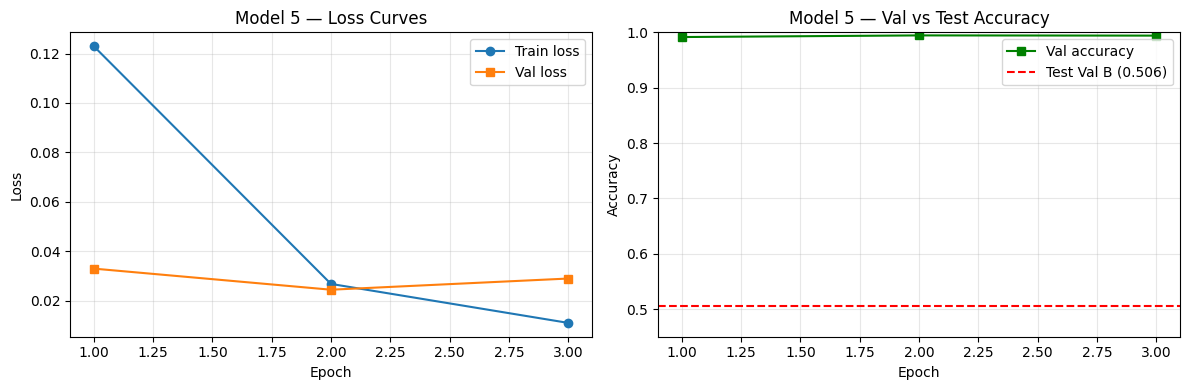

In [ ]:
# Model 5 — Train, Validation, and Test Scores

# --- Per-epoch train loss and monitor (val) accuracy from Trainer log ---
import pandas as pd
import matplotlib.pyplot as plt

log_df     = pd.DataFrame(trainer.state.log_history)
train_logs = log_df[log_df["loss"].notna()][["epoch", "loss"]].reset_index(drop=True)
eval_logs  = log_df[log_df["eval_loss"].notna()][["epoch", "eval_loss", "eval_accuracy"]].reset_index(drop=True)

print("Model 5 — DistilBERT Per-epoch Train and Validation Results")
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12} {'Val Acc':>10}")
print("-" * 48)
for _, erow in eval_logs.iterrows():
    trow = train_logs[train_logs["epoch"] <= erow["epoch"]].iloc[-1]
    print(f"{int(erow['epoch']):<8} {trow['loss']:>12.4f} {erow['eval_loss']:>12.4f} {erow['eval_accuracy']:>10.4f}")

# --- Test: Val B (original Cloze 2-way) ---
cloze_rows_5b = []
for _, row in cloze_val.iterrows():
    context = " ".join([str(row[f"InputSentence{i}"]) for i in range(1, 5)])
    cloze_rows_5b.append({
        "context":  context,
        "ending_a": str(row["RandomFifthSentenceQuiz1"]),
        "ending_b": str(row["RandomFifthSentenceQuiz2"]),
        "label":    1 if row["AnswerRightEnding"] == 1 else 0
    })

cloze_df_5b = pd.DataFrame(cloze_rows_5b)
cloze_ds_5b = Dataset.from_pandas(cloze_df_5b.reset_index(drop=True))
cloze_ds_5b = cloze_ds_5b.map(tokenize_pairwise, batched=True)
keep_cols_5b = ["input_ids", "attention_mask"]
if "token_type_ids" in cloze_ds_5b.column_names:
    keep_cols_5b.append("token_type_ids")
cloze_ds_5b = cloze_ds_5b.remove_columns([c for c in cloze_ds_5b.column_names if c not in keep_cols_5b])
cloze_ds_5b.set_format("torch")

preds_5b = np.argmax(trainer.predict(cloze_ds_5b).predictions, axis=-1)
acc_5b   = (preds_5b == cloze_df_5b["label"].values).mean()

print(f"\nModel 5 — Test Val B (Cloze 2-way, {len(cloze_val)} stories): {acc_5b:.4f}")
print()
print("Note: Val Acc = binary classification on ROC monitor split.")
print("Test Val B is the original Cloze 2-way task — lower scores expected.")

# --- Training curve plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Train loss")
ax1.plot(eval_logs["epoch"],  eval_logs["eval_loss"], marker="s", label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Model 5 — Loss Curves")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker="s", color="green", label="Val accuracy")
ax2.axhline(acc_5b, color="red", linestyle="--", label=f"Test Val B ({acc_5b:.3f})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Model 5 — Val vs Test Accuracy")
ax2.set_ylim(0.45, 1.0); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Model 5C: Per-type pairwise on Cloze val generated negatives
# Uses PairwiseDataset (fast) instead of .map()
cloze_pair_5c    = make_pairwise_dataset(cloze_long)
cloze_ds_5c_fast = PairwiseDataset(cloze_pair_5c, tokenizer)

preds_5c_raw          = np.argmax(trainer.predict(cloze_ds_5c_fast).predictions, axis=-1)
cloze_pair_5c         = cloze_pair_5c.copy()
cloze_pair_5c["pred"] = preds_5c_raw

# Only label=1 rows — gold is on the left, pred=1 means model correctly prefers gold
cloze_eval_5c = cloze_pair_5c[cloze_pair_5c["label"] == 1].copy()

print("Model 5C — Overall pairwise accuracy:", (cloze_eval_5c["pred"] == 1).mean())
print("\nModel 5C — Per-type pairwise accuracy:")
print(cloze_eval_5c.groupby("type")["pred"].apply(lambda x: (x == 1).mean()))

Model 5C — Overall pairwise accuracy: 0.9910884786760026

Model 5C — Per-type pairwise accuracy:
type
causal       0.997454
sentiment    0.987906
state        0.985996
temporal     0.992998
Name: pred, dtype: float64


---
## Model 6: Pairwise RoBERTa

**How it works:**
- Fine-tunes `roberta-base` on pairs of endings simultaneously
- Same pairwise setup as DistilBERT: input = (context + [SEP] + ending_a, ending_b)
- RoBERTa is a more robustly trained version of BERT — no next-sentence prediction,
  trained on more data with dynamic masking
- Expected to be stronger than DistilBERT on sentence-pair classification tasks

In [ ]:
# !pip install -q transformers datasets accelerate
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import torch
from torch.utils.data import Dataset as TorchDataset
import numpy as np

# Reuse make_pairwise_dataset from earlier
roberta_name = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_name, use_fast=True)
roberta_model     = AutoModelForSequenceClassification.from_pretrained(roberta_name, num_labels=2)
roberta_collator  = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

def tokenize_roberta(examples):
    left  = [c + " </s> " + a for c, a in zip(examples["context"], examples["ending_a"])]
    right = examples["ending_b"]
    return roberta_tokenizer(left, right, truncation=True, max_length=128)

class RoBERTaPairwiseDataset(TorchDataset):
    def __init__(self, df, tokenizer, max_length=128):
        left  = [c + " </s> " + a for c, a in zip(df["context"].astype(str), df["ending_a"].astype(str))]
        right = list(df["ending_b"].astype(str))
        self.encodings = tokenizer(left, right, truncation=True, max_length=max_length, padding=False)
        self.labels    = list(df["label"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

roberta_train_ds   = RoBERTaPairwiseDataset(train_pair, roberta_tokenizer)
roberta_monitor_ds = RoBERTaPairwiseDataset(monitor_pair, roberta_tokenizer)
print("RoBERTa datasets tokenized and ready.")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa datasets tokenized and ready.


In [ ]:
# Train RoBERTa
roberta_training_args = TrainingArguments(
    output_dir                  = "./pairwise_roberta",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    logging_strategy            = "epoch",
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    load_best_model_at_end      = True,
    report_to                   = "none"
)

roberta_trainer = Trainer(
    model           = roberta_model,
    args            = roberta_training_args,
    train_dataset   = roberta_train_ds,
    eval_dataset    = roberta_monitor_ds,
    data_collator   = roberta_collator,
    compute_metrics = lambda ep: {"accuracy": (np.argmax(ep[0], axis=-1) == ep[1]).mean()}
)

roberta_trainer.train()
print("\nRoBERTa training complete.")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.076771,0.037425,0.993292
2,0.015586,0.029983,0.994711
3,0.003907,0.033151,0.995485


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


RoBERTa training complete.


Model 6 — RoBERTa Per-epoch Train and Validation Results
Epoch      Train Loss     Val Loss    Val Acc
------------------------------------------------
1              0.0768       0.0374     0.9933
2              0.0156       0.0300     0.9947
3              0.0039       0.0332     0.9955


Map:   0%|          | 0/1571 [00:00<?, ? examples/s]


Model 6 — Test Val B (Cloze 2-way, 1571 stories): 0.5697


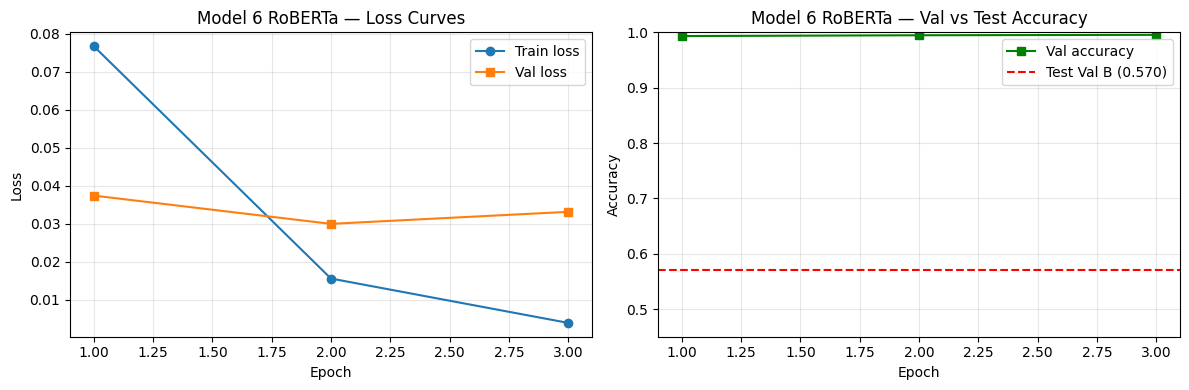

In [ ]:
# Model 6 — Train, Validation, and Test Scores
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset

log_df     = pd.DataFrame(roberta_trainer.state.log_history)
train_logs = log_df[log_df["loss"].notna()][["epoch", "loss"]].reset_index(drop=True)
eval_logs  = log_df[log_df["eval_loss"].notna()][["epoch", "eval_loss", "eval_accuracy"]].reset_index(drop=True)

print("Model 6 — RoBERTa Per-epoch Train and Validation Results")
print(f"{'Epoch':<8} {'Train Loss':>12} {'Val Loss':>12} {'Val Acc':>10}")
print("-" * 48)
for _, erow in eval_logs.iterrows():
    trow = train_logs[train_logs["epoch"] <= erow["epoch"]].iloc[-1]
    print(f"{int(erow['epoch']):<8} {trow['loss']:>12.4f} {erow['eval_loss']:>12.4f} {erow['eval_accuracy']:>10.4f}")

# Test: Val B
cloze_rows_6b = []
for _, row in cloze_val.iterrows():
    context = " ".join([str(row[f"InputSentence{i}"]) for i in range(1, 5)])
    cloze_rows_6b.append({
        "context":  context,
        "ending_a": str(row["RandomFifthSentenceQuiz1"]),
        "ending_b": str(row["RandomFifthSentenceQuiz2"]),
        "label":    1 if row["AnswerRightEnding"] == 1 else 0
    })

cloze_df_6b = pd.DataFrame(cloze_rows_6b)
cloze_ds_6b = Dataset.from_pandas(cloze_df_6b.reset_index(drop=True))
cloze_ds_6b = cloze_ds_6b.map(tokenize_roberta, batched=True)
keep_cols_6b = ["input_ids", "attention_mask"]
if "token_type_ids" in cloze_ds_6b.column_names:
    keep_cols_6b.append("token_type_ids")
cloze_ds_6b = cloze_ds_6b.remove_columns([c for c in cloze_ds_6b.column_names if c not in keep_cols_6b])
cloze_ds_6b.set_format("torch")

preds_6b = np.argmax(roberta_trainer.predict(cloze_ds_6b).predictions, axis=-1)
acc_6b   = (preds_6b == cloze_df_6b["label"].values).mean()

print(f"\nModel 6 — Test Val B (Cloze 2-way, {len(cloze_val)} stories): {acc_6b:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_logs["epoch"], train_logs["loss"], marker="o", label="Train loss")
ax1.plot(eval_logs["epoch"],  eval_logs["eval_loss"], marker="s", label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Model 6 RoBERTa — Loss Curves")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker="s", color="green", label="Val accuracy")
ax2.axhline(acc_6b, color="red", linestyle="--", label=f"Test Val B ({acc_6b:.3f})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Model 6 RoBERTa — Val vs Test Accuracy")
ax2.set_ylim(0.45, 1.0); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Model 6C — Per-type pairwise on Cloze val generated negatives
cloze_pair_6c    = make_pairwise_dataset(cloze_long)
cloze_ds_6c_fast = RoBERTaPairwiseDataset(cloze_pair_6c, roberta_tokenizer)

preds_6c_raw          = np.argmax(roberta_trainer.predict(cloze_ds_6c_fast).predictions, axis=-1)
cloze_pair_6c         = cloze_pair_6c.copy()
cloze_pair_6c["pred"] = preds_6c_raw

cloze_eval_6c = cloze_pair_6c[cloze_pair_6c["label"] == 1].copy()

print("Model 6C — Overall pairwise accuracy:", (cloze_eval_6c["pred"] == 1).mean())
print("\nModel 6C — Per-type pairwise accuracy:")
print(cloze_eval_6c.groupby("type")["pred"].apply(lambda x: (x == 1).mean()))

Model 6C — Overall pairwise accuracy: 0.9971355824315723

Model 6C — Per-type pairwise accuracy:
type
causal       0.998727
sentiment    0.997454
state        0.994908
temporal     0.997454
Name: pred, dtype: float64


---
## Results Summary (All Models)

In [ ]:
# Full results summary including RoBERTa
print("=== Val B: Cloze 2-way Accuracy ===")
print(f"  Model 1 — Lexical Overlap:   {evaluate_1b_cloze(cloze_val):.4f}")
print(f"  Model 2 — TF-IDF Cosine:     {evaluate_2b_cloze(cloze_val):.4f}")
print(f"  Model 3 — TF-IDF + LR:       {acc_3b:.4f}")
print(f"  Model 4 — SBERT:             {evaluate_4b_cloze(cloze_val):.4f}")
print(f"  Model 5 — DistilBERT:        {acc_5b:.4f}")
print(f"  Model 6 — RoBERTa:           {acc_6b:.4f}")

type6c = cloze_eval_6c.groupby("type")["pred"].apply(lambda x: (x == 1).mean())

print("\n=== Fake Detection Accuracy (Per-type) ===")
print(f"{'Model':<28} {'Temporal':>10} {'Causal':>8} {'State':>8} {'Sentiment':>10}")
print("-" * 68)
for name, scores in [
    ("1 - Lexical Overlap",     by_type_1c),
    ("2 - TF-IDF Cosine",       by_type_2c),
    ("3 - TF-IDF + LR",         results_3c_df.groupby('type')['correct'].mean()),
    ("4 - SBERT",               by_type_4c),
    ("5 - DistilBERT",          cloze_eval_5c.groupby('type')['pred'].apply(lambda x: (x==1).mean())),
    ("6 - RoBERTa",             type6c),
]:
    print(f"{name:<28} {scores['temporal']:>10.3f} {scores['causal']:>8.3f} {scores['state']:>8.3f} {scores['sentiment']:>10.3f}")

=== Val B: Cloze 2-way Accuracy ===
  Model 1 — Lexical Overlap:   0.5169
  Model 2 — TF-IDF Cosine:     0.5165
  Model 3 — TF-IDF + LR:       0.5926
  Model 4 — SBERT:             0.5939
  Model 5 — DistilBERT:        0.5060
  Model 6 — RoBERTa:           0.5697

=== Fake Detection Accuracy (Per-type) ===
Model                          Temporal   Causal    State  Sentiment
--------------------------------------------------------------------
1 - Lexical Overlap               0.066    0.095    0.113      0.134
2 - TF-IDF Cosine                 0.310    0.480    0.474      0.553
3 - TF-IDF + LR                   0.983    0.977    0.961      0.973
4 - SBERT                         0.238    0.411    0.443      0.542
5 - DistilBERT                    0.993    0.997    0.986      0.988
6 - RoBERTa                       0.997    0.999    0.995      0.997


---
## Analysis & Diagnostics

The following cells add:
1. Consolidated results table (Val B + Val C side by side)
2. Val B bar chart and Val C per-type heatmap
3. Val B vs Val C gap scatter (key finding)
4. Statistical significance testing (binomial test)
5. Qualitative error analysis — examples per reasoning type

### 1. Consolidated Results Table

In [ ]:
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd

types = ["temporal", "causal", "state", "sentiment"]

# --- collect Val B scores ---
val_b_scores = {
    "1 - Lexical Overlap":      evaluate_1b_cloze(cloze_val),
    "2 - TF-IDF Cosine":        evaluate_2b_cloze(cloze_val),
    "3 - TF-IDF + LR":          acc_3b,
    "4 - SBERT":                evaluate_4b_cloze(cloze_val),
    "5 - DistilBERT Pairwise":  acc_5b,
    "6 - RoBERTa":              acc_6b,
}

# --- collect Val C per-type scores ---
type3c  = results_3c_df.groupby("type")["correct"].mean()
type5c  = cloze_eval_5c.groupby("type")["pred"].apply(lambda x: (x == 1).mean())
type6c  = cloze_eval_6c.groupby("type")["pred"].apply(lambda x: (x == 1).mean())

val_c_by_model = {
    "1 - Lexical Overlap":      by_type_1c,
    "2 - TF-IDF Cosine":        by_type_2c,
    "3 - TF-IDF + LR":          type3c,
    "4 - SBERT":                by_type_4c,
    "5 - DistilBERT Pairwise":  type5c,
    "6 - RoBERTa":              type6c,
}

rows = []
for model_name in val_b_scores:
    row = {"Model": model_name, "Val B": round(val_b_scores[model_name], 4)}
    for t in types:
        row[f"C-{t[:4]}"] = round(val_c_by_model[model_name][t], 4)
    row["C-overall"] = round(np.mean([val_c_by_model[model_name][t] for t in types]), 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")
print("Val B = original Cloze 2-way accuracy")
print("C-*   = Val C pairwise accuracy: gold vs LLM-generated negative of each type")
print()
display(summary_df)

Val B = original Cloze 2-way accuracy
C-*   = Val C pairwise accuracy: gold vs LLM-generated negative of each type



,Val B,C-temp,C-caus,C-stat,C-sent,C-overall
Model,,,,,,
1 - Lexical Overlap,0.5169,0.0656,0.0948,0.1127,0.1343,0.1018
2 - TF-IDF Cosine,0.5165,0.3100,0.4799,0.4736,0.5532,0.4542
3 - TF-IDF + LR,0.5926,0.9828,0.9771,0.9612,0.9733,0.9736
4 - SBERT,0.5939,0.2381,0.4112,0.4430,0.5423,0.4087
5 - DistilBERT Pairwise,0.5060,0.9930,0.9975,0.9860,0.9879,0.9911
6 - RoBERTa,0.5697,0.9975,0.9987,0.9949,0.9975,0.9971


### 2. Val B Bar Chart and Val C Heatmap

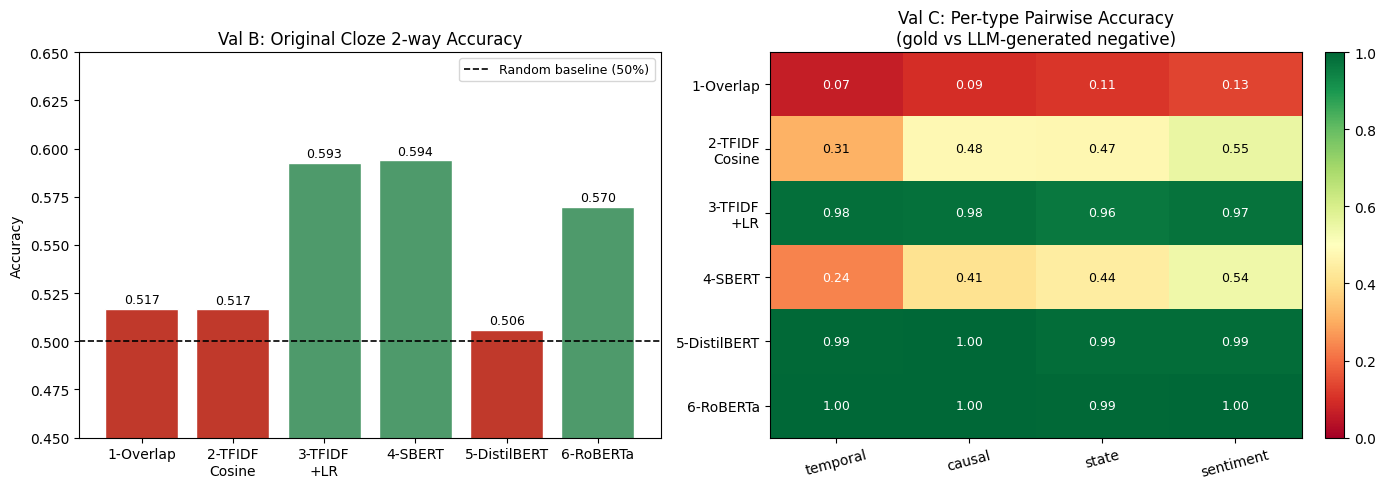

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_labels = ["1-Overlap", "2-TFIDF\nCosine", "3-TFIDF\n+LR", "4-SBERT", "5-DistilBERT", "6-RoBERTa"]

val_b_vals   = list(val_b_scores.values())
type_labels  = ["temporal", "causal", "state", "sentiment"]
val_c_matrix = np.array([
    [val_c_by_model[m][t] for t in type_labels]
    for m in val_c_by_model
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: Val B ---
bar_colors = ["#4e9a6b" if v > 0.55 else "#c0392b" for v in val_b_vals]
axes[0].bar(model_labels, val_b_vals, color=bar_colors, edgecolor="white")
axes[0].axhline(0.5, color="black", linestyle="--", linewidth=1.2, label="Random baseline (50%)")
axes[0].set_ylim(0.45, 0.65)
axes[0].set_title("Val B: Original Cloze 2-way Accuracy", fontsize=12)
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=9)
for i, v in enumerate(val_b_vals):
    axes[0].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=9)

# --- right: Val C heatmap ---
im = axes[1].imshow(val_c_matrix, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_xticks(range(4));  axes[1].set_xticklabels(type_labels, rotation=15)
axes[1].set_yticks(range(6));  axes[1].set_yticklabels(model_labels)
axes[1].set_title("Val C: Per-type Pairwise Accuracy\n(gold vs LLM-generated negative)", fontsize=12)
for i in range(6):
    for j in range(4):
        v = val_c_matrix[i, j]
        axes[1].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                     color="black" if 0.25 < v < 0.75 else "white")

plt.tight_layout()
plt.show()

### 3. Val B vs Val C Gap — Key Finding

Models 3 and 5 score near-perfectly on Val C (97–99%) but only 53–59% on Val B.
This gap reveals that trained models likely learned to detect **GPT-4o-mini's writing style**
rather than genuine narrative reasoning — both train and Val C negatives come from the same generator.
The unsupervised models (2 and 4) show no such gap and produce the most honest per-type signal.

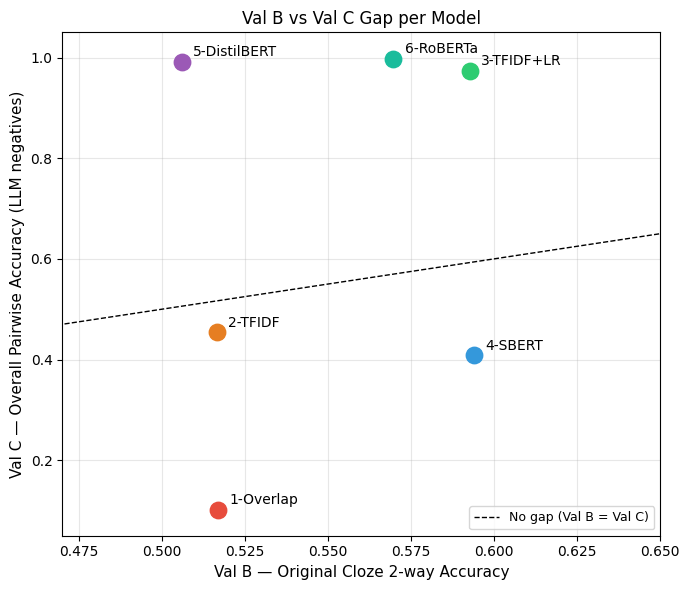


Gap (Val C - Val B) per model:
  1-Overlap           Val B=0.517  Val C=0.102  gap=+-0.415
  2-TFIDF             Val B=0.517  Val C=0.454  gap=+-0.062
  3-TFIDF+LR          Val B=0.593  Val C=0.974  gap=+0.381
  4-SBERT             Val B=0.594  Val C=0.409  gap=+-0.185
  5-DistilBERT        Val B=0.506  Val C=0.991  gap=+0.485
  6-RoBERTa           Val B=0.570  Val C=0.997  gap=+0.427


In [ ]:
import matplotlib.pyplot as plt

val_c_overall = [np.mean([val_c_by_model[m][t] for t in type_labels]) for m in val_c_by_model]
colors  = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6", "#1abc9c"]

labels  = list(val_b_scores.keys())
short   = ["1-Overlap", "2-TFIDF", "3-TFIDF+LR", "4-SBERT", "5-DistilBERT", "6-RoBERTa"]


fig, ax = plt.subplots(figsize=(7, 6))
for i, (vb, vc, col, lbl) in enumerate(zip(val_b_vals, val_c_overall, colors, short)):
    ax.scatter(vb, vc, color=col, s=140, zorder=5)
    ax.annotate(lbl, (vb, vc), textcoords="offset points", xytext=(8, 4), fontsize=10)

# diagonal = no gap line
lims = [0.45, 1.05]
ax.plot(lims, lims, "k--", linewidth=1, label="No gap (Val B = Val C)")
ax.set_xlim(0.47, 0.65); ax.set_ylim(0.05, 1.05)
ax.set_xlabel("Val B — Original Cloze 2-way Accuracy", fontsize=11)
ax.set_ylabel("Val C — Overall Pairwise Accuracy (LLM negatives)", fontsize=11)
ax.set_title("Val B vs Val C Gap per Model", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nGap (Val C - Val B) per model:")
for m, vb, vc in zip(short, val_b_vals, val_c_overall):
    print(f"  {m:<18}  Val B={vb:.3f}  Val C={vc:.3f}  gap=+{vc - vb:.3f}")

### 4. Statistical Significance Testing

We use a one-sided **binomial test** (H₀: accuracy = 0.5) to check whether each model performs
significantly above the random baseline on Val B (n = 1571) and on Val C per reasoning type
for the two unsupervised models (n ≈ 1571 per type).

Supervised model Val C scores are excluded here because near-perfect accuracy on LLM-generated
negatives does not indicate genuine reasoning; significance there would be misleading.

In [ ]:
from scipy.stats import binomtest

# --- Val B ---
n_b = len(cloze_val)
print(f"Val B significance (n={n_b}, one-sided, H0: acc=0.5)")
print(f"{'Model':<28} {'Acc':>7} {'k':>6} {'p-value':>10} {'Sig?':>8}")
print("-" * 65)
for model_name, acc in val_b_scores.items():
    k      = round(acc * n_b)
    result = binomtest(k, n_b, 0.5, alternative="greater")
    sig    = "* YES" if result.pvalue < 0.05 else "no"
    print(f"{model_name:<28} {acc:>7.4f} {k:>6} {result.pvalue:>10.4f} {sig:>8}")

# --- Val C per type: Models 2 and 4 only ---
n_c = cloze_long[cloze_long["type"] == "temporal"].shape[0]
print(f"\nVal C per-type significance — unsupervised models only (n={n_c} per type)")
print(f"{'Model / Type':<32} {'Acc':>7} {'p-value':>10} {'Sig?':>8}")
print("-" * 60)
for m_name, type_scores in [("2 - TF-IDF Cosine", val_c_by_model["2 - TF-IDF Cosine"]),
                              ("4 - SBERT",         val_c_by_model["4 - SBERT"])]:
    for t in type_labels:
        acc    = type_scores[t]
        k      = round(acc * n_c)
        result = binomtest(k, n_c, 0.5, alternative="greater")
        sig    = "* YES" if result.pvalue < 0.05 else "no"
        print(f"{m_name + ' / ' + t:<32} {acc:>7.4f} {result.pvalue:>10.4f} {sig:>8}")
    print()

Val B significance (n=1571, one-sided, H0: acc=0.5)
Model                            Acc      k    p-value     Sig?
-----------------------------------------------------------------
1 - Lexical Overlap           0.5169    812     0.0948       no
2 - TF-IDF Cosine             0.5165    812     0.0948       no
3 - TF-IDF + LR               0.5926    931     0.0000    * YES
4 - SBERT                     0.5939    933     0.0000    * YES
5 - DistilBERT Pairwise       0.5060    795     0.3249       no
6 - RoBERTa                   0.5697    895     0.0000    * YES

Val C per-type significance — unsupervised models only (n=1571 per type)
Model / Type                         Acc    p-value     Sig?
------------------------------------------------------------
2 - TF-IDF Cosine / temporal      0.3100     1.0000       no
2 - TF-IDF Cosine / causal        0.4799     0.9468       no
2 - TF-IDF Cosine / state         0.4736     0.9830       no
2 - TF-IDF Cosine / sentiment     0.5532     0.0000    

### 5. Qualitative Error Analysis

We examine Val C errors from **Model 2 (TF-IDF Cosine)** — the best unsupervised model that
cannot overfit to the generator's style. Errors here reflect cases where the LLM-generated
negative is lexically similar enough to fool surface matching, meaning genuine reasoning
would be needed to reject it.

We show 3 failure examples per reasoning type.

In [ ]:
# Fast error analysis using batch TF-IDF transforms
def get_errors_df(df, vectorizer):
    df    = df.copy()
    ctx   = sk_normalize(vectorizer.transform(df["context"].astype(str)))
    gold  = sk_normalize(vectorizer.transform(df["gold_ending"].astype(str)))
    neg   = sk_normalize(vectorizer.transform(df["generated_ending"].astype(str)))
    df["gold_score"] = ctx.multiply(gold).sum(axis=1).A1
    df["neg_score"]  = ctx.multiply(neg).sum(axis=1).A1
    df["correct"]    = df["gold_score"] > df["neg_score"]
    return df[~df["correct"]].reset_index(drop=True)

errors_m2 = get_errors_df(cloze_long, tfidf_sim_vectorizer)

for neg_type in type_labels:
    subset = errors_m2[errors_m2["type"] == neg_type].head(3)
    print(f"{'=' * 70}")
    print(f"TYPE: {neg_type.upper()}  —  {len(errors_m2[errors_m2['type'] == neg_type])} total errors "
          f"({100 * (1 - val_c_by_model['2 - TF-IDF Cosine'][neg_type]):.1f}% error rate)")
    print(f"{'=' * 70}")
    for i, row in subset.iterrows():
        print(f"\nContext:     {row['context']}")
        print(f"Gold:        {row['gold_ending']}")
        print(f"Neg ({neg_type[:5]}): {row['generated_ending']}")
    print()

TYPE: TEMPORAL  —  1084 total errors (69.0% error rate)

Context:     Rick grew up in a troubled household. He never found good support in family, and turned to gangs. It wasn't long before Rick got shot in a robbery. The incident caused him to turn a new leaf.
Gold:        He is happy now.
Neg (tempo): Before the incident, Rick was already happy and leading a fulfilling life.

Context:     Laverne needs to prepare something for her friend's party. She decides to bake a batch of brownies. She chooses a recipe and follows it closely. Laverne tests one of the brownies to make sure it is delicious.
Gold:        The brownies are so delicious Laverne eats two of them.
Neg (tempo): Laverne tests one of the brownies after she has already eaten all of them.

Context:     Sarah had been dreaming of visiting Europe for years. She had finally saved enough for the trip. She landed in Spain and traveled east across the continent. She didn't like how different everything was.
Gold:        Sarah deci

### 6. Per-type Error Rates — Unsupervised Models

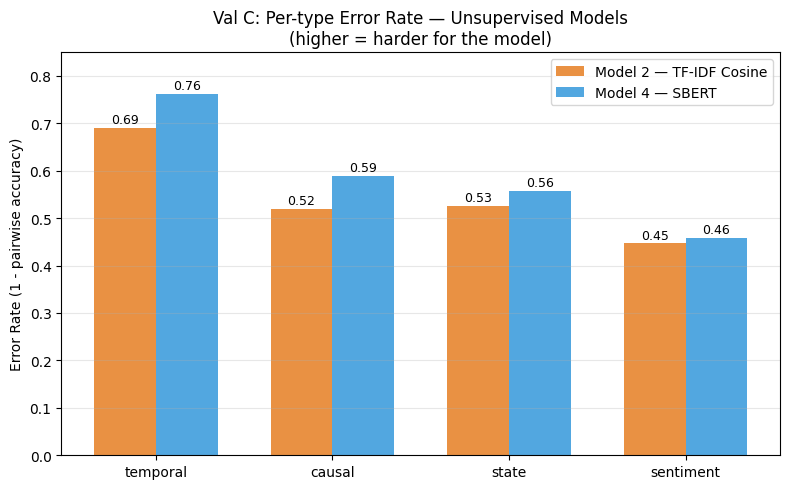


Key pattern: temporal has the highest error rate for both models,
sentiment the lowest — consistent with the hypothesis in the proposal.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Error rate = 1 - accuracy
error_m2 = [1 - val_c_by_model["2 - TF-IDF Cosine"][t] for t in type_labels]
error_m4 = [1 - val_c_by_model["4 - SBERT"][t]         for t in type_labels]

x     = np.arange(len(type_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, error_m2, width, label="Model 2 — TF-IDF Cosine", color="#e67e22", alpha=0.85)
bars2 = ax.bar(x + width/2, error_m4, width, label="Model 4 — SBERT",         color="#3498db", alpha=0.85)

ax.set_ylabel("Error Rate (1 - pairwise accuracy)")
ax.set_title("Val C: Per-type Error Rate — Unsupervised Models\n(higher = harder for the model)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(type_labels)
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey pattern: temporal has the highest error rate for both models,")
print("sentiment the lowest — consistent with the hypothesis in the proposal.")

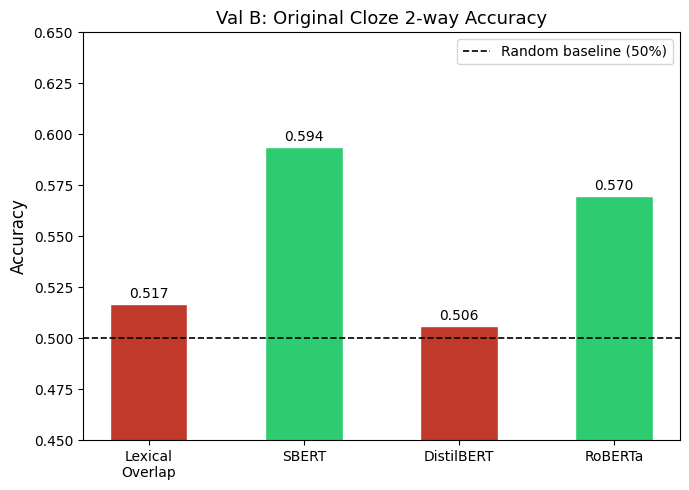

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Lexical\nOverlap", "SBERT", "DistilBERT", "RoBERTa"]
val_b  = [
    evaluate_1b_cloze(cloze_val),
    evaluate_4b_cloze(cloze_val),
    acc_5b,
    acc_6b
]
colors = ["#c0392b" if v < 0.55 else "#2ecc71" for v in val_b]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models, val_b, color=colors, edgecolor="white", width=0.5)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.2, label="Random baseline (50%)")
ax.set_ylim(0.45, 0.65)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Val B: Original Cloze 2-way Accuracy", fontsize=13)
ax.legend(fontsize=10)
for bar, v in zip(bars, val_b):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("val_b_bar.png", dpi=150)
plt.show()


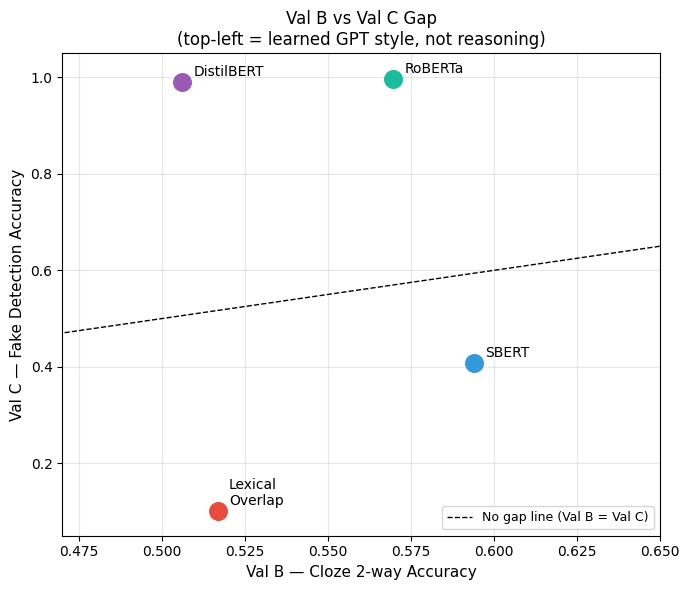

In [ ]:
import matplotlib.pyplot as plt

models_short = ["Lexical\nOverlap", "SBERT", "DistilBERT", "RoBERTa"]
val_b_4 = [
    evaluate_1b_cloze(cloze_val),
    evaluate_4b_cloze(cloze_val),
    acc_5b,
    acc_6b
]
val_c_4 = [
    np.mean(by_type_1c),
    np.mean(by_type_4c),
    np.mean([type5c[t] for t in type_labels]),
    np.mean([type6c[t] for t in type_labels])
]

colors = ["#e74c3c", "#3498db", "#9b59b6", "#1abc9c"]

fig, ax = plt.subplots(figsize=(7, 6))
for vb, vc, col, lbl in zip(val_b_4, val_c_4, colors, models_short):
    ax.scatter(vb, vc, color=col, s=160, zorder=5)
    ax.annotate(lbl, (vb, vc), textcoords="offset points", xytext=(8, 4), fontsize=10)

lims = [0.45, 1.05]
ax.plot(lims, lims, "k--", linewidth=1, label="No gap line (Val B = Val C)")
ax.set_xlim(0.47, 0.65); ax.set_ylim(0.05, 1.05)
ax.set_xlabel("Val B — Cloze 2-way Accuracy", fontsize=11)
ax.set_ylabel("Val C — Fake Detection Accuracy", fontsize=11)
ax.set_title("Val B vs Val C Gap\n(top-left = learned GPT style, not reasoning)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("val_b_vs_val_c.png", dpi=150)
plt.show()


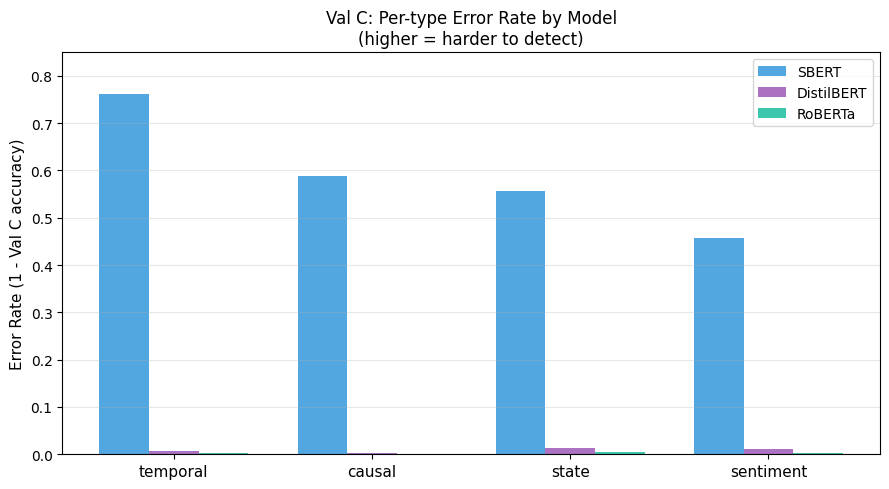

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

type_labels = ["temporal", "causal", "state", "sentiment"]
error_sbert  = [1 - by_type_4c[t]   for t in type_labels]
error_distil = [1 - type5c[t]        for t in type_labels]
error_roberta= [1 - type6c[t]        for t in type_labels]

x     = np.arange(len(type_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width, error_sbert,   width, label="SBERT",      color="#3498db", alpha=0.85)
ax.bar(x,         error_distil,  width, label="DistilBERT", color="#9b59b6", alpha=0.85)
ax.bar(x + width, error_roberta, width, label="RoBERTa",    color="#1abc9c", alpha=0.85)

ax.set_ylabel("Error Rate (1 - Val C accuracy)", fontsize=11)
ax.set_title("Val C: Per-type Error Rate by Model\n(higher = harder to detect)", fontsize=12)
ax.set_xticks(x); ax.set_xticklabels(type_labels, fontsize=11)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_type_error.png", dpi=150)
plt.show()
